<a href="https://colab.research.google.com/github/DilshanBotheju/CSACP_Project/blob/main/HomicidePatternRecognizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import folium
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [4]:
#Load relevant datasets
homicide_data_path = "/content/drive/MyDrive/DSGP/datasets/preprocessed_dataset.csv"
homicide_data = pd.read_csv(homicide_data_path, encoding = "latin-1")
homicide_data.head()

,City,State,Year,Month,Incident,Crime Type,Victim Sex,Victim Age,Victim Race,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
0,San Bernardino,California,2005,7,1,Murder or Manslaughter,Male,18,White,Male,0.0,White,Acquaintance,Handgun,1,0,Teen (13-19),NaN
1,Harris,Texas,2013,5,3,Murder or Manslaughter,Male,27,White,Male,0.0,White,Acquaintance,Firearm,0,0,Young Adult (20-29),NaN
2,St. Francis,Arkansas,2001,6,1,Murder or Manslaughter,Male,42,Black,Male,18.0,Black,Acquaintance,Handgun,0,0,Adult (30-49),Teen (13-19)
3,Pima,Arizona,1998,3,6,Murder or Manslaughter,Male,44,White,Male,0.0,White,Acquaintance,Handgun,0,0,Adult (30-49),NaN
4,Okanogan,Washington,1999,8,1,Murder or Manslaughter,Female,15,White,Male,20.0,White,Girlfriend,Rifle,0,0,Teen (13-19),Young Adult (20-29)


EDA (Exploratory Data Analysis)

<ipython-input-5-372c2f28047c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=homicide_data, y="Crime Type", order=homicide_data["Crime Type"].value_counts().index, palette="coolwarm")


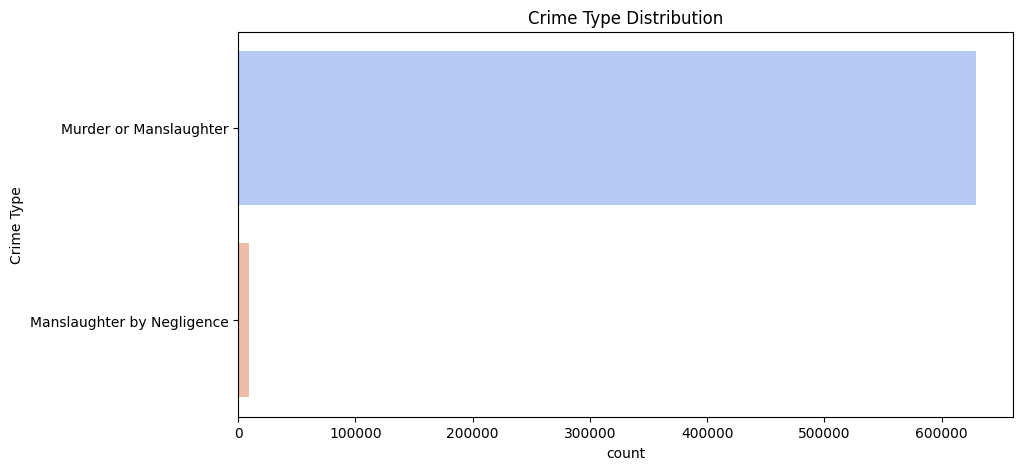

In [5]:
# Distribution of homicide crime types
plt.figure(figsize=(10,5))
sns.countplot(data=homicide_data, y="Crime Type", order=homicide_data["Crime Type"].value_counts().index, palette="coolwarm")
plt.title("Crime Type Distribution")
plt.show()

<ipython-input-6-b69b9ed5197d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=homicide_data, y="Weapon", order=homicide_data["Weapon"].value_counts().head(10).index, palette="magma")


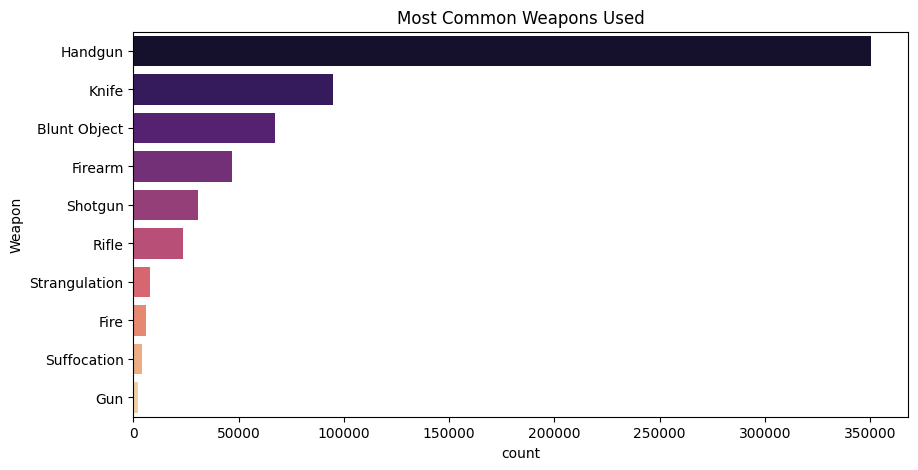

In [6]:
# Plotting most common weapons used
plt.figure(figsize=(10,5))
sns.countplot(data=homicide_data, y="Weapon", order=homicide_data["Weapon"].value_counts().head(10).index, palette="magma")
plt.title("Most Common Weapons Used")
plt.show()

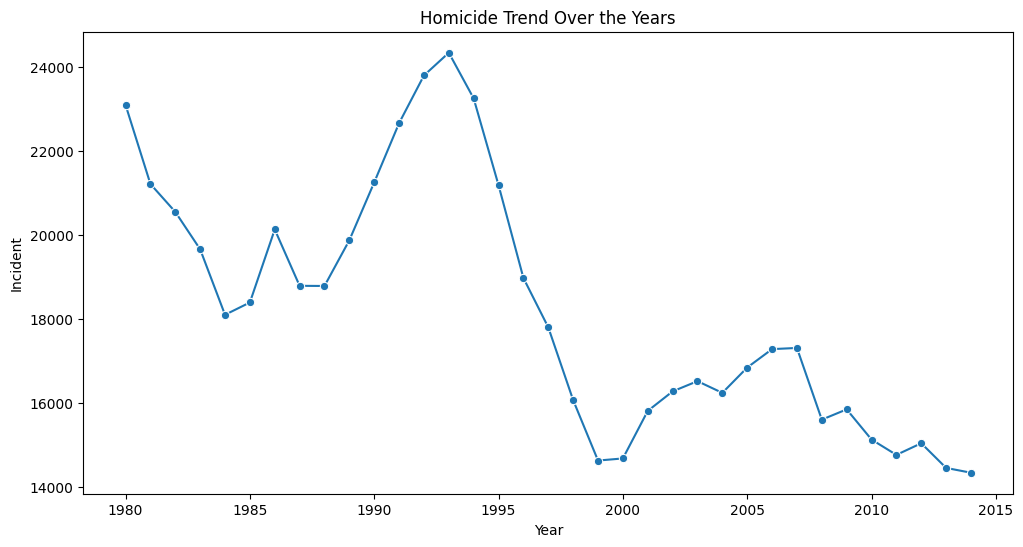

In [7]:
# Identify homicide trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(x="Year", y="Incident", data=homicide_data.groupby("Year")["Incident"].count().reset_index(), marker="o")
plt.title("Homicide Trend Over the Years")
plt.show()

In [8]:
# Drop unnecessary columns
homicide_data = homicide_data.drop(columns=["Perpetrator Age","Victim Age","Incident"])

In [9]:
# View data
homicide_data.head()

,City,State,Year,Month,Crime Type,Victim Sex,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
0,San Bernardino,California,2005,7,Murder or Manslaughter,Male,White,Male,White,Acquaintance,Handgun,1,0,Teen (13-19),NaN
1,Harris,Texas,2013,5,Murder or Manslaughter,Male,White,Male,White,Acquaintance,Firearm,0,0,Young Adult (20-29),NaN
2,St. Francis,Arkansas,2001,6,Murder or Manslaughter,Male,Black,Male,Black,Acquaintance,Handgun,0,0,Adult (30-49),Teen (13-19)
3,Pima,Arizona,1998,3,Murder or Manslaughter,Male,White,Male,White,Acquaintance,Handgun,0,0,Adult (30-49),NaN
4,Okanogan,Washington,1999,8,Murder or Manslaughter,Female,White,Male,White,Girlfriend,Rifle,0,0,Teen (13-19),Young Adult (20-29)


In [10]:
# Check null values
homicide_data.isnull().sum()

,0
City,0
State,0
Year,0
Month,0
Crime Type,0
Victim Sex,0
Victim Race,0
Perpetrator Sex,0
Perpetrator Race,0
Relationship,0


In [11]:
# Getting a sample percentage of data to preprocess
data_percentage = 1
homicide_data = homicide_data.sample(frac=data_percentage, random_state=42)

In [12]:
# Replacing NA with Unknown to identify null columns
homicide_data.replace( np.nan,"Unknown", inplace=True)

In [13]:
# View data
homicide_data.head()

,City,State,Year,Month,Crime Type,Victim Sex,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
484984,Baltimore city,Maryland,1996,8,Murder or Manslaughter,Male,Black,Male,White,Acquaintance,Handgun,0,0,Senior (50+),Unknown
608445,Essex,New Jersey,2013,9,Murder or Manslaughter,Male,White,Male,Black,Stranger,Handgun,0,0,Young Adult (20-29),Teen (13-19)
417612,Wayne,Michigan,1997,11,Murder or Manslaughter,Male,Black,Male,White,Acquaintance,Firearm,0,0,Young Adult (20-29),Unknown
372692,Dade,Florida,1995,12,Murder or Manslaughter,Male,White,Male,Black,Son,Blunt Object,0,0,Child (0-12),Adult (30-49)
402028,Los Angeles,California,2002,11,Murder or Manslaughter,Male,White,Male,White,Stranger,Handgun,0,0,Teen (13-19),Teen (13-19)


In [14]:
# View dataset info
homicide_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 638454 entries, 484984 to 121958
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   City                   638454 non-null  object
 1   State                  638454 non-null  object
 2   Year                   638454 non-null  int64 
 3   Month                  638454 non-null  int64 
 4   Crime Type             638454 non-null  object
 5   Victim Sex             638454 non-null  object
 6   Victim Race            638454 non-null  object
 7   Perpetrator Sex        638454 non-null  object
 8   Perpetrator Race       638454 non-null  object
 9   Relationship           638454 non-null  object
 10  Weapon                 638454 non-null  object
 11  Victim Count           638454 non-null  int64 
 12  Perpetrator Count      638454 non-null  int64 
 13  Victim Age Group       638454 non-null  object
 14  Perpetrator Age Group  638454 non-null  object
dtype

In [15]:
from sklearn.preprocessing import LabelEncoder


# Label encoding categorical features
categorical_cols = [ "City", "State", "Crime Type","Victim Sex", "Victim Race","Perpetrator Sex", "Perpetrator Race", "Relationship", "Weapon","Perpetrator Age Group","Victim Age Group"]
encoder_dict = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    homicide_data[col] = encoder.fit_transform(homicide_data[col])
    encoder_dict[col] = encoder



In [16]:
# Viewing the data
homicide_data.head()

,City,State,Year,Month,Crime Type,Victim Sex,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
484984,87,20,1996,8,1,1,1,1,3,0,8,0,0,2,4
608445,539,30,2013,9,1,1,3,1,1,25,8,0,0,5,3
417612,1695,22,1997,11,1,1,1,1,3,0,6,0,0,5,4
372692,425,9,1995,12,1,1,3,1,1,20,0,0,0,1,0
402028,946,4,2002,11,1,1,3,1,3,25,8,0,0,3,3


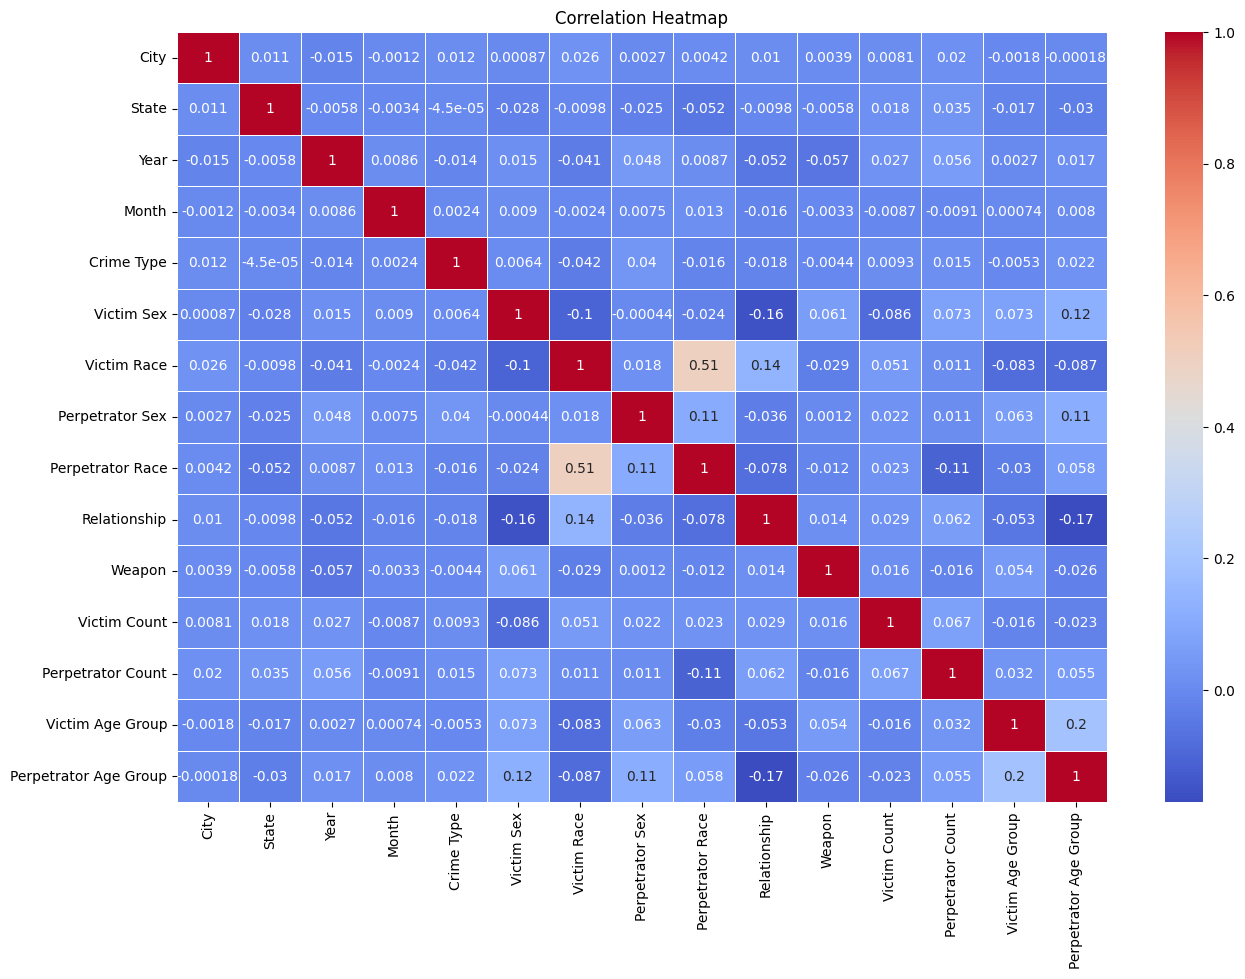

In [17]:
# Getting correlation matrix
correlation_matrix = homicide_data.corr()

# Plotting heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Model Building

In [18]:
# Select features
features = ['City', 'State', 'Year', 'Month', 'Crime Type', 'Victim Sex',
            'Victim Race', 'Perpetrator Sex', 'Perpetrator Race',
            'Relationship', 'Weapon', 'Victim Count', 'Perpetrator Count',
            'Victim Age Group', 'Perpetrator Age Group']

X = homicide_data[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

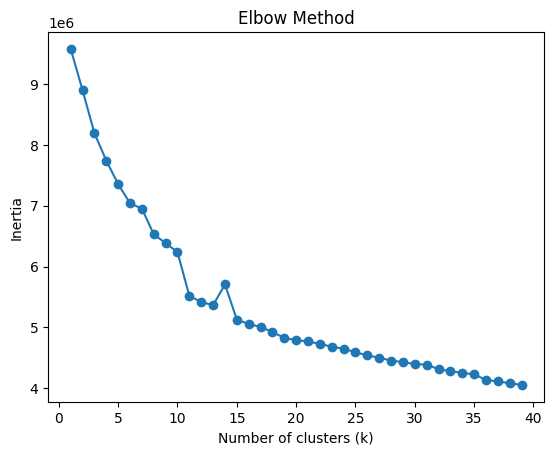

In [19]:
# Using elbow method to identify clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 40):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 40), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [20]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(n_clusters=15, random_state=42)
kmeans.fit(X_scaled)

# Assign clusters to your data
homicide_data["Cluster"] = kmeans.labels_

In [21]:
print(homicide_data["Cluster"].value_counts())

Cluster
3     87072
6     67584
7     57044
5     54171
4     53178
8     53060
12    51056
9     51002
2     42970
1     37566
14    24412
10    23170
11    21759
13     9079
0      5331
Name: count, dtype: int64


In [22]:
cluster_summary = homicide_data.groupby("Cluster").mean()
print(cluster_summary)

                City      State         Year     Month  Crime Type  \
Cluster                                                              
0         931.441193  25.100919  1996.411555  6.516976    0.993810   
1         851.226987  28.720066  1995.676915  6.736970    1.000000   
2         924.566791  23.910542  1996.452734  6.520991    1.000000   
3         858.716223  21.155607  1998.667390  6.788773    1.000000   
4         882.281075  24.075238  1994.182876  6.448456    1.000000   
5         967.408484  13.772664  1995.485020  6.680050    1.000000   
6         905.128877  26.031502  1994.326956  6.586810    1.000000   
7         948.314634  20.152794  1994.513498  6.431246    1.000000   
8         900.743498  22.159461  1994.665888  6.577667    1.000000   
9        1237.876260  29.473256  1998.125701  6.514882    1.000000   
10        936.309668  24.855071  1998.267242  6.474191    0.999827   
11        911.710465  24.512524  1995.451859  6.490556    1.000000   
12        563.391531

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


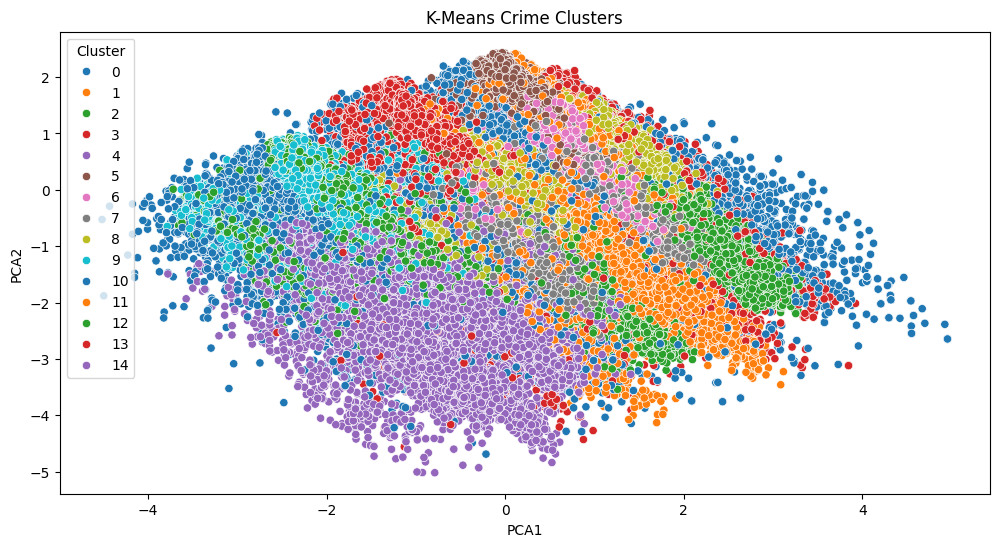

In [23]:
# Visualize with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
homicide_data['PCA1'] = X_pca[:, 0]
homicide_data['PCA2'] = X_pca[:, 1]

# Plot K-Means Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='Cluster', palette='tab10')
plt.title('K-Means Crime Clusters')
plt.show()

<ipython-input-24-2828eef811a9>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='tab10')


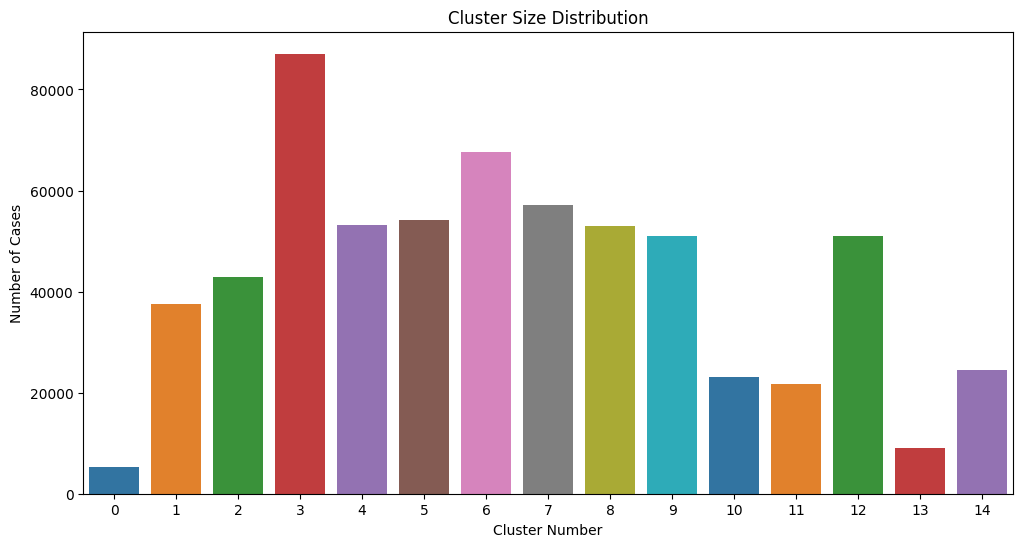

In [24]:
# Count the number of cases per cluster
cluster_counts = homicide_data['Cluster'].value_counts().sort_index()

# Bar chart of cluster sizes
plt.figure(figsize=(12, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='tab10')
plt.xlabel('Cluster Number')
plt.ylabel('Number of Cases')
plt.title('Cluster Size Distribution')
plt.show()


In [55]:
for cluster in range(15):
    print(f"Cluster {cluster} summary:")
    print(homicide_data[homicide_data['Cluster'] == cluster].describe())

Cluster 0 summary:
              City        State         Year        Month   Crime Type  \
count  5331.000000  5331.000000  5331.000000  5331.000000  5331.000000   
mean    931.441193    25.100919  1996.411555     6.516976     0.993810   
std     455.353773    14.780519    10.322593     3.421355     0.078441   
min       0.000000     0.000000  1980.000000     1.000000     0.000000   
25%     575.000000    10.000000  1988.000000     4.000000     1.000000   
50%     959.000000    29.000000  1995.000000     7.000000     1.000000   
75%    1243.000000    38.000000  2006.000000     9.000000     1.000000   
max    1779.000000    50.000000  2014.000000    12.000000     1.000000   

        Victim Sex  Victim Race  Perpetrator Sex  Perpetrator Race  \
count  5331.000000  5331.000000      5331.000000       5331.000000   
mean      0.548678     2.294316         0.943163          2.373663   
std       0.497672     1.011864         0.231553          0.974888   
min       0.000000     0.000000   

Advanced

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


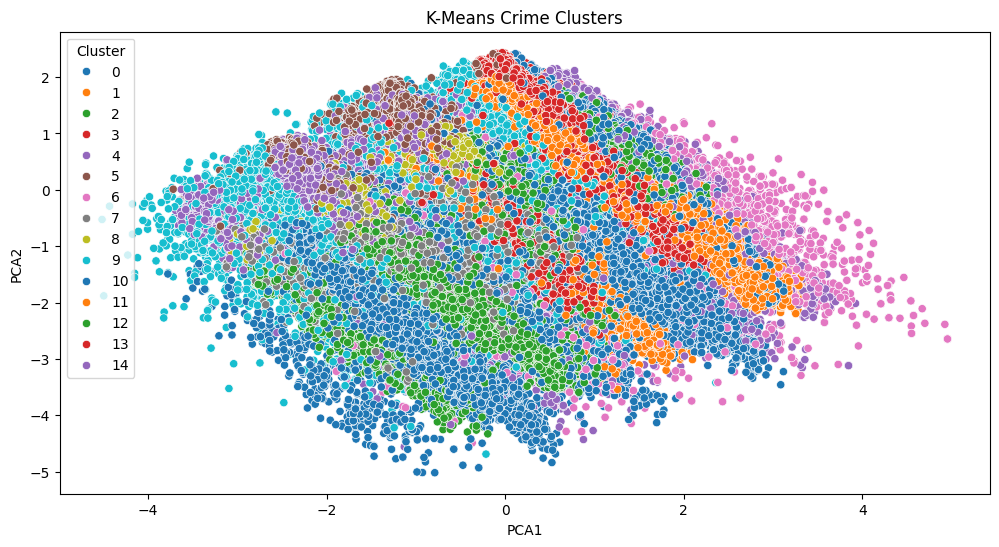

In [23]:
# K-Means Clustering
kmeans = KMeans(n_clusters=15, random_state=42)
homicide_data['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
homicide_data['PCA1'] = X_pca[:, 0]
homicide_data['PCA2'] = X_pca[:, 1]

# Plot K-Means Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='Cluster', palette='tab10')
plt.title('K-Means Crime Clusters')
plt.show()

In [24]:
homicide_data['Cluster'].value_counts()

,count
Cluster,
13,64649
1,61212
10,58651
4,55459
8,52187
3,49601
5,48000
2,46982
12,46345


In [25]:
top_clusters = homicide_data['Cluster'].value_counts().head(2).index.tolist()
homicide_data['Serial_Crime'] = homicide_data['Cluster'].apply(lambda x: 1 if x in top_clusters else 0)

In [26]:
# Value count for serial crime
homicide_data['Serial_Crime'].value_counts()

,count
Serial_Crime,
0,512593
1,125861


In [28]:
# Use features and target
y = homicide_data['Serial_Crime']

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [ ]:
# Build KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict on training data
y_train_pred = knn.predict(X_train)

# Predict on test data
y_test_pred = knn.predict(X_test)

# Accuracy report
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nTesting Accuracy:", accuracy_score(y_test, y_test_pred))

# Detailed classification report
print("\nClassification Report (Test Data):\n")
print(classification_report(y_test, y_test_pred))


Training Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    358782
           1       1.00      1.00      1.00     88135

    accuracy                           1.00    446917
   macro avg       1.00      1.00      1.00    446917
weighted avg       1.00      1.00      1.00    446917


Testing Accuracy: 0.997253794306061
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    153811
           1       0.99      0.99      0.99     37726

    accuracy                           1.00    191537
   macro avg       1.00      0.99      1.00    191537
weighted avg       1.00      1.00      1.00    191537



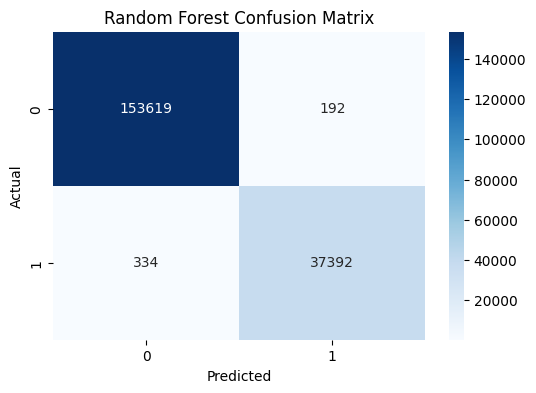

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Accuracy Reports
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

print("\nTesting Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=2, min_samples=5)
homicide_data['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# Plot DBSCAN Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='DBSCAN_Cluster', palette='tab10')
plt.title('DBSCAN Crime Clusters')
plt.show()

NameError: name 'DBSCAN' is not defined

In [ ]:
# Check cluster composition
for cluster in homicide_data['KMeans_Cluster'].unique():
    print(f"\nCluster {cluster} sample crimes:")
    print(homicide_data[homicide_data['KMeans_Cluster'] == cluster][features].head())